### AUTHOR: JOO YOUNG HAN
## libraries used

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import ace_tools_open as tools

## getting list of all disasters

In [21]:
csvFilename = 'philip_disas.csv'
csvDirectory = '{}'.format(csvFilename)
philip_disasters_df = pd.read_csv(csvDirectory)
philip_econ_df = pd.read_csv('philip_econ.csv')

disaster_types = philip_disasters_df['Disaster Type'].dropna().unique()

# Display the list
all_disasters = disaster_types.tolist()
print(all_disasters)

['Storm', 'Earthquake', 'Mass movement (wet)', 'Fire (Industrial)', 'Fire (Miscellaneous)', 'Volcanic activity', 'Flood', 'Road', 'Collapse (Miscellaneous)', 'Poisoning', 'Epidemic', 'Drought', 'Air', 'Explosion (Miscellaneous)', 'Water', 'Miscellaneous accident (General)', 'Mass movement (dry)', 'Explosion (Industrial)', 'Collapse (Industrial)', 'Infestation', 'Chemical spill', 'Rail', 'Wildfire', 'Oil spill']


## graph frequency of storms throughout the years

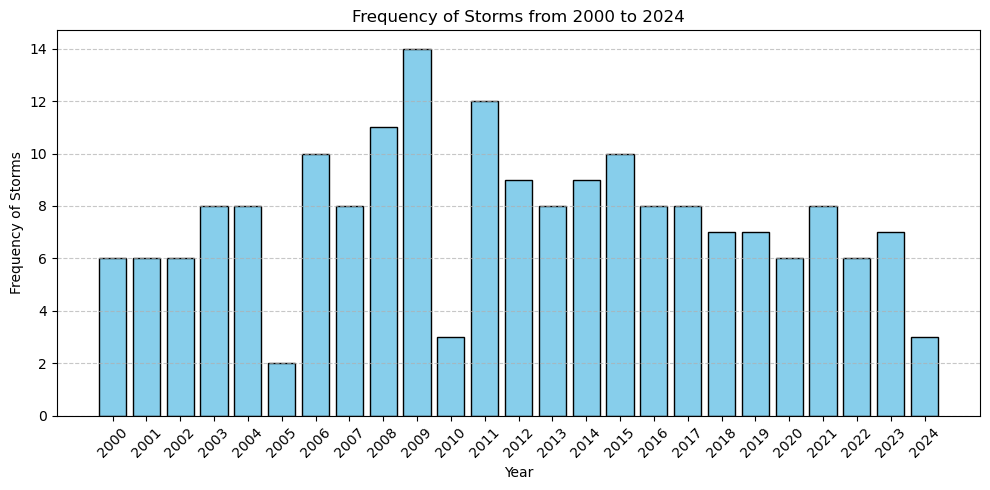

In [24]:
def storm_frequency(type):
    # Filter the required columns for the given disaster type and years 2011+
    data = philip_disasters_df[
        (philip_disasters_df['Disaster Type'] == type) & 
        philip_disasters_df['Year'].notna() & 
        (philip_disasters_df['Year'] >= 2000)
    ].copy()

    # Ensure 'Year' is numeric
    data['Year'] = pd.to_numeric(data['Year'], errors='coerce')

    # Drop rows with invalid data
    data = data.dropna(subset=['Year'])

    if not data.empty:
        # Count the number of storms per year
        frequency = data['Year'].value_counts().sort_index()

        # Convert to DataFrame for visualization
        frequency_df = frequency.reset_index()
        frequency_df.columns = ['Year', 'Storm Count']

        # Plot the frequency of storms
        plt.figure(figsize=(10, 5))
        plt.bar(frequency_df['Year'], frequency_df['Storm Count'], color='skyblue', edgecolor='black')
        plt.xlabel('Year')
        plt.ylabel('Frequency of Storms')
        plt.title(f'Frequency of Storms from 2000 to 2024')
        plt.xticks(frequency_df['Year'], rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid data available for disaster type '{type}'.")

storm_frequency('Storm')



## most powerful storms discovery

In [34]:
# Filter data for storms from 2000 onwards with valid 'Total Affected' and 'Location'
storms_data = philip_disasters_df[
    (philip_disasters_df['Year'] >= 2000) &
    (philip_disasters_df['Disaster Type'] == 'Storm') &
    (philip_disasters_df['Total Affected'].notna()) &
    (philip_disasters_df['Location'].notna())
]

# Find the storm with the highest 'Total Affected' for each year
storms_max_affected = storms_data.loc[
    storms_data.groupby('Year')['Total Affected'].idxmax(),
    ['Year', 'Event Name', 'Location', 'Total Affected']
].sort_values(by='Year')

# Display the result to the user
tools.display_dataframe_to_user(name="Storms with Most Affected People from 2000 Onwards", dataframe=storms_max_affected)


Storms with Most Affected People from 2000 Onwards


## insight
Although 2009 recorded 14 storms, making it a notable year for storm frequency, the most severe storm occurred in 2013: Typhoon Haiyan. Known as one of the strongest tropical cyclones ever recorded, Haiyan caused unprecedented devastation, particularly in the Philippines. Its intensity far surpassed any storm recorded in 2009, highlighting that while storm frequency is significant, the severity and impact of individual storms are often more consequential. 

## comparing to philippines economy

In [38]:
# Recreate the filtered dataset
columns_2000_onwards = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + \
    [str(year) for year in range(2000, 2024)]

valid_data_2000_onwards = philip_econ_df[columns_2000_onwards].dropna(how='all', subset=[str(year) for year in range(2000, 2024)])

# Remove all rows where any of the columns from 2000 onwards are NaN
cleaned_data_2000_onwards = valid_data_2000_onwards.dropna(subset=[str(year) for year in range(2000, 2024)], how='any')

# Display the cleaned dataset to the user
tools.display_dataframe_to_user(name="Cleaned Data from 2000 Onwards (No NaN Rows)", dataframe=cleaned_data_2000_onwards)


Cleaned Data from 2000 Onwards (No NaN Rows)


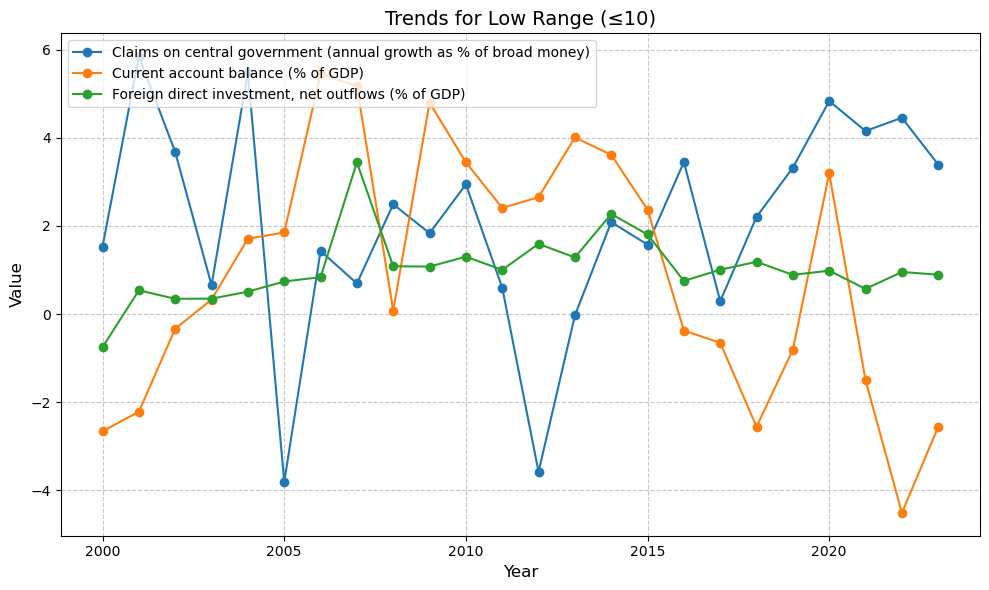

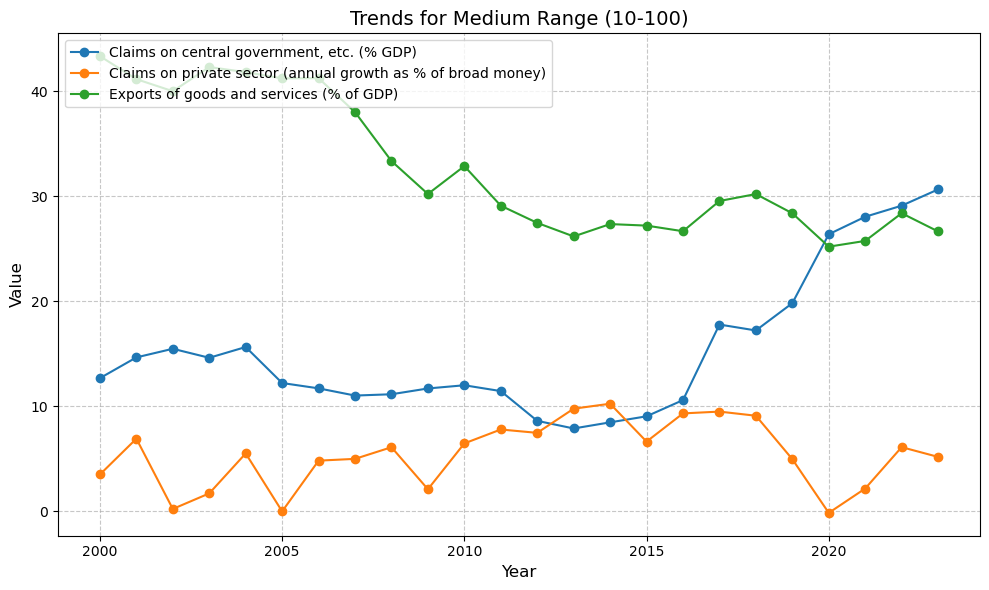

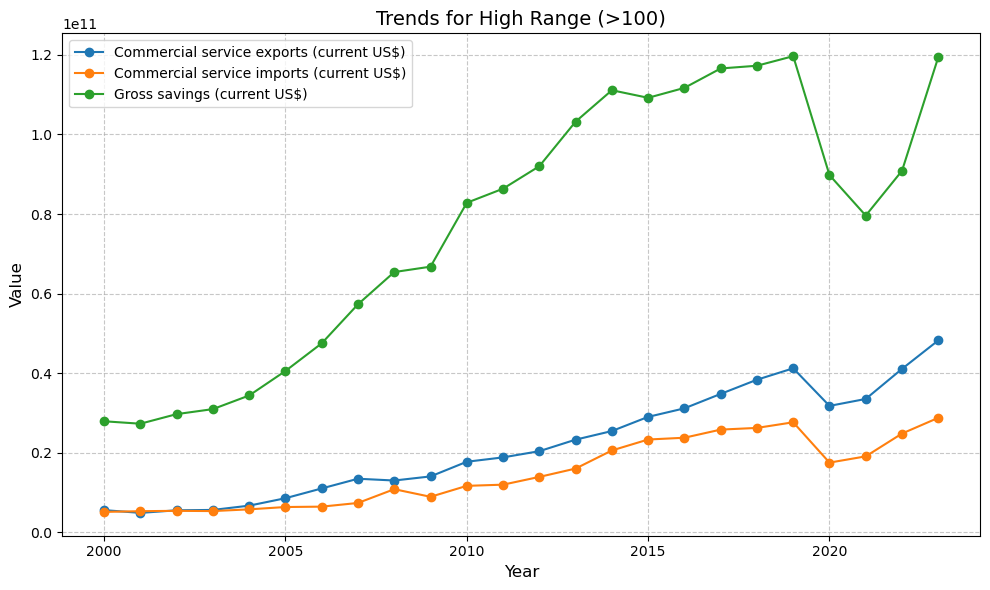

In [39]:
# Select the specific rows by their indices
selected_rows = cleaned_data_2000_onwards.loc[[182, 183, 186, 208, 209, 287, 400, 462, 562]]

# Prepare data for plotting
years = [str(year) for year in range(2000, 2024)]
selected_data = selected_rows[years].transpose()

# Set column names for better visualization
selected_data.columns = selected_rows['Indicator Name'].values
selected_data.index = selected_data.index.astype(int)  # Convert year strings to integers


# Determine ranges of values for better grouping
value_ranges = selected_data.max() - selected_data.min()

# Define thresholds to group similar ranges
low_range = value_ranges[value_ranges <= 10]
medium_range = value_ranges[(value_ranges > 10) & (value_ranges <= 100)]
high_range = value_ranges[value_ranges > 100]

# Group data based on value ranges
groups = {
    'Low Range (≤10)': selected_data[low_range.index],
    'Medium Range (10-100)': selected_data[medium_range.index],
    'High Range (>100)': selected_data[high_range.index],
}

# Plot each group separately
for group_name, group_data in groups.items():
    if not group_data.empty:
        plt.figure(figsize=(10, 6))
        for column in group_data.columns:
            plt.plot(group_data.index, group_data[column], label=column, marker='o')

        plt.title(f'Trends for {group_name}', fontsize=14)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Value', fontsize=12)
        plt.legend(loc='upper left', fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
